In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input



In [19]:
df = pd.read_excel("/content/Sales_Analysis_Dataset (3).xlsx")

print(df.head())
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

   Order_ID Order_Date Customer_Name Customer_Segment Product_Name  \
0  ORD00001 2023-08-17     Suresh 90      Home Office       Laptop   
1  ORD00002 2023-03-03    Suresh 430         Consumer      Monitor   
2  ORD00003 2024-07-23     Sneha 105         Consumer       Laptop   
3  ORD00004 2025-01-05      Vijay 81      Home Office   Headphones   
4  ORD00005 2025-01-10     Priya 876         Consumer      Pen Set   

     Category Sub_Category Region        City  Quantity  ...      Sales  \
0  Technology    Computers   East      Ranchi         4  ...  195496.56   
1  Technology  Accessories  North  Chandigarh         4  ...   59495.44   
2  Technology    Computers  North  Chandigarh         7  ...  415866.46   
3  Technology  Accessories   East       Patna         1  ...    2324.90   
4  Stationery      Writing  North       Delhi         2  ...     292.28   

      Profit  Payment_Method  Year Month  Month_Number Quarter  Profit_Margin  \
0   44744.06             UPI  2023   Aug       

In [20]:
X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount",
        "Profit",
        "Profit_Margin",
        "Year",
        "Month_Number"
    ]
]


In [21]:
y = df["Sales"]


print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Quantity  Unit_Price  Discount     Profit  Profit_Margin  Year  \
0         4    59602.61      0.18   44744.06          22.89  2023   
1         4    15024.10      0.01    7362.22          12.37  2023   
2         7    61884.89      0.04  120845.34          29.06  2024   
3         1     2672.30      0.13     683.72          29.41  2025   
4         2      155.47      0.06      41.99          14.37  2025   

   Month_Number  
0             8  
1             3  
2             7  
3             1  
4             1  

Target:
0    195496.56
1     59495.44
2    415866.46
3      2324.90
4       292.28
Name: Sales, dtype: float64


In [22]:
print("\nMissing values:")
print(X.isnull().sum())
print(y.isnull().sum())



Missing values:
Quantity         0
Unit_Price       0
Discount         0
Profit           0
Profit_Margin    0
Year             0
Month_Number     0
dtype: int64
0


In [23]:
X = X.fillna(X.median())
y = y.fillna(y.median())

print("\nMissing values handled.")


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Missing values handled.

Training data: (4000, 7)
Testing data: (1000, 7)


In [24]:
X_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

In [25]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
)


print("\nFeature and target scaling completed.")




Feature and target scaling completed.


In [26]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))



In [27]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Display model
model.summary()


# Train model
history = model.fit(
    X_train,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3108 - mae: 0.2573 - val_loss: 0.0506 - val_mae: 0.1327
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0217 - mae: 0.0916 - val_loss: 0.0121 - val_mae: 0.0768
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0100 - mae: 0.0665 - val_loss: 0.0068 - val_mae: 0.0578
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0064 - mae: 0.0539 - val_loss: 0.0050 - val_mae: 0.0498
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0049 - mae: 0.0477 - val_loss: 0.0037 - val_mae: 0.0451
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - mae: 0.0436 - val_loss: 0.0036 - val_mae: 0.0443
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0036 - mae: 0.0413 - val_loss: 0.0039 - val_mae: 0.0449
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0388 - val_loss: 0.0027 - val_mae: 0.0381
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [28]:
loss, mae = model.evaluate(
    X_test,
    y_test_scaled,
    verbose=0
)

print("\nTest Loss:", loss)
print("Test MAE (Scaled):", mae)


# Prediction
y_pred_scaled = model.predict(X_test)

# Convert prediction back to original Sales values
y_pred = y_scaler.inverse_transform(
    y_pred_scaled
).flatten()


print("\nPredicted Sales:")
print(y_pred[:10])




Test Loss: 0.001717329490929842
Test MAE (Scaled): 0.023542337119579315
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Predicted Sales:
[ 27171.547 493911.72   50519.703   4688.812 159738.17  193722.05
  54424.977  18347.254  10727.565  83146.67 ]


In [29]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)


print("\nFinal Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)




Final Evaluation:
MAE: 2374.6375407660676
MSE: 17472262.487679694
RMSE: 4179.983551125494
R² Score: 0.9983397819266311



Actual vs Predicted:
   Actual Sales  Predicted Sales
0      24852.10     27171.546875
1     492568.78    493911.718750
2      50784.48     50519.703125
3       5186.46      4688.812012
4     164672.46    159738.171875
5     195823.16    193722.046875
6      52471.86     54424.976562
7      21966.33     18347.253906
8       9830.41     10727.565430
9      87008.77     83146.671875


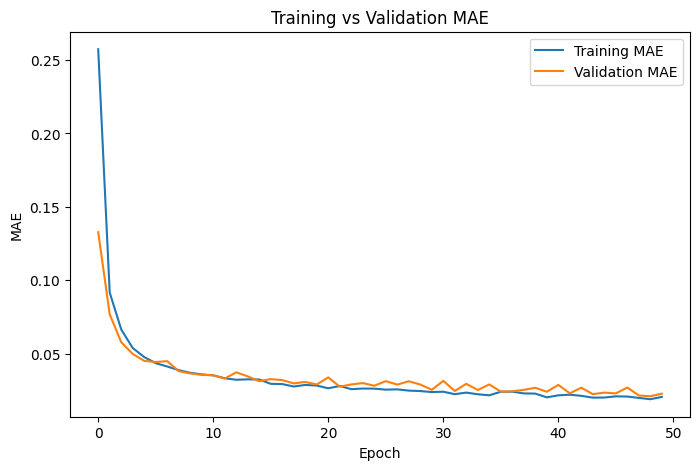

In [30]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print("\nActual vs Predicted:")
print(results.head(10))


# Plot Training vs Validation MAE
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()


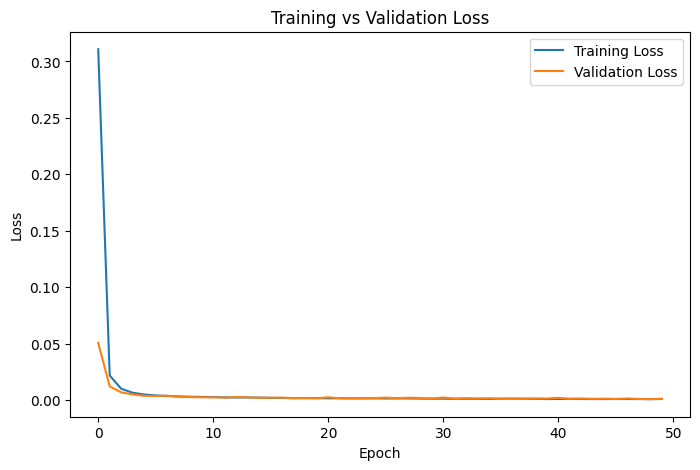

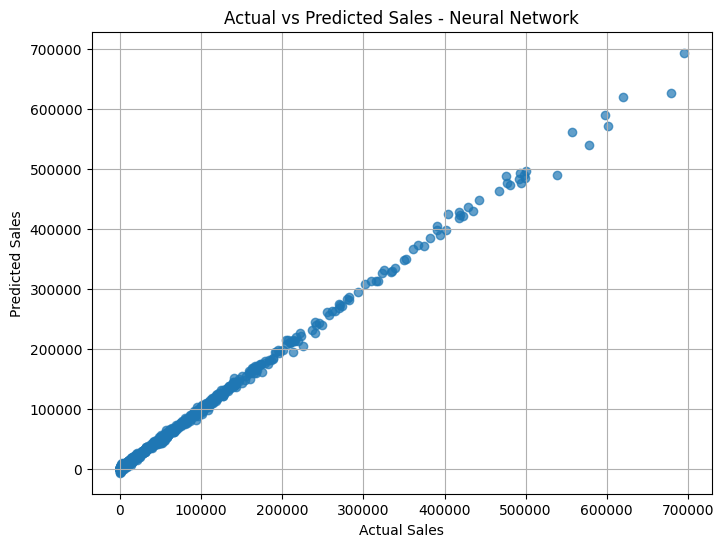

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales - Neural Network"
)

plt.grid(True)

plt.show()


In [32]:
results.to_excel(
    "Neural_Network_Sales_Predictions.xlsx",
    index=False
)

print("\nPrediction results saved successfully.")


# Save model
model.save(
    "sales_neural_network_model.keras"
)

print("Model saved successfully.")


Prediction results saved successfully.
Model saved successfully.
